# Turn-Averaging Sensitivity Analysis (2 Hz MBB)

How does the number/selection of averaged turns affect B1, b2, b3 at injection?
Validate the choice **N_LAST_TURNS = 18** (= 9 s at 2 Hz, ≈ 9.5 × τ₁ for NCS b3).

> **DAQ label swap (2026-02-25 campaign):**
> The CSV files use DAQ labels, which were swapped in this campaign:
> - File `CS` → **body** segment (TF ≈ 0.386 T/kA, inside yoke)
> - File `NCS` → **fringe** segment (TF ≈ 0.065 T/kA, mostly outside yoke)
>
> This notebook uses the file labels as-is. All plots say "CS" / "NCS" = DAQ labels.

| Dataset | Source |
|---------|--------|
| **200 GeV** | `MBB/2026-02-25_2Hz/200GeV` |
| **26 GeV** | `MBB/2026-02-25_2Hz/26GeV` |

| # | Section |
|---|--------|
| 1 | Configuration & Imports |
| 2 | Data Loading |
| 3 | Injection Plateau Overview |
| 4 | N_LAST Convergence Sweep |
| 5 | First-N vs Last-N Comparison |
| 6 | Eddy Contamination Detection |
| 7 | Current Stability Check |
| 8 | **Tail Trimming Sensitivity** |
| 9 | Eddy Fit Start Sensitivity |
| 10 | Cross-Energy Comparison |
| 11 | Recommendations |

---
## 1. Configuration & Imports

In [1]:
# -- DAQ label swap (2026-02-25 campaign) --
# File "CS"  = body segment   (TF ≈ 0.386 T/kA)
# File "NCS" = fringe segment (TF ≈ 0.065 T/kA)
# We use file labels as-is throughout this notebook.
SEGMENTS = ['CS', 'NCS']
ENERGIES = ['200GeV', '26GeV']
QUANTITIES = ['B1_T', 'b2_units', 'b3_units']
Q_LABELS  = {'B1_T': 'B1 (T)', 'b2_units': 'b2 (units)', 'b3_units': 'b3 (units)'}
T_PER_TURN = 0.5  # seconds per turn at 2 Hz
N_LAST_DEFAULT = 18  # current choice

# Eddy "settled" thresholds — the residual |A*exp(-t/tau)| must be below
# this level for a turn to be considered eddy-free.
# For harmonics (units): 1e-2 units (sub-unit precision).
# For B1 (T): 1e-6 T ≈ 0.01 units at B1 ~ 0.1 T (body), ≈ 0.5 units at B1 ~ 0.02 T (fringe).
EDDY_SAFE_THRESHOLDS = {
    'b2_units': 1e-2,
    'b3_units': 1e-2,
    'B1_T':     1e-6,
}

import sys
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

%matplotlib widget
plt.rcParams.update({"figure.figsize": (14, 5), "axes.grid": True, "grid.alpha": 0.3, "figure.dpi": 100})

REPO_ROOT = Path(".").resolve()
while REPO_ROOT != REPO_ROOT.parent:
    if (REPO_ROOT / "pyproject.toml").exists() or (REPO_ROOT / ".git").exists(): break
    REPO_ROOT = REPO_ROOT.parent

if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

from rotating_coil_analyzer.analysis.utility_functions import eddy_model

OUT_BASE = REPO_ROOT / "output" / "MBB" / "2026-02-25_2Hz"
print(f"REPO_ROOT: {REPO_ROOT}")
print(f"Output base: {OUT_BASE}")
print(f"Eddy settled thresholds: {EDDY_SAFE_THRESHOLDS}")

REPO_ROOT: C:\Users\albellel\python-projects\rotating-coil-analyzer
Output base: C:\Users\albellel\python-projects\rotating-coil-analyzer\output\MBB\2026-02-25_2Hz
Eddy settled thresholds: {'b2_units': 0.01, 'b3_units': 0.01, 'B1_T': 1e-06}


---
## 2. Data Loading

In [2]:
# Load eddy injection data and eddy fits for both energies
inj_data = {}   # (energy, segment) -> DataFrame
fits_data = {}  # energy -> DataFrame

for energy in ENERGIES:
    edir = OUT_BASE / energy
    fits_data[energy] = pd.read_csv(edir / "eddy_fits_mean.csv")
    for seg in SEGMENTS:
        df = pd.read_csv(edir / f"eddy_injection_{seg}.csv")
        # Keep only valid supercycles (sc_idx >= 0)
        df = df[df['sc_idx'] >= 0].copy()
        inj_data[(energy, seg)] = df
        print(f"{energy}/{seg}: {len(df)} rows, {df['sc_idx'].nunique()} supercycles, "
              f"max turn_in_group={df['turn_in_group'].max():.0f}")

200GeV/CS: 1010 rows, 35 supercycles, max turn_in_group=48
200GeV/NCS: 1010 rows, 35 supercycles, max turn_in_group=48
26GeV/CS: 1074 rows, 35 supercycles, max turn_in_group=52
26GeV/NCS: 1074 rows, 35 supercycles, max turn_in_group=52


In [3]:
def get_fit_params(fits_df, segment, quantity):
    """Extract eddy fit parameters for a given segment and quantity."""
    row = fits_df[(fits_df['segment'] == segment) & (fits_df['quantity'] == quantity)]
    if row.empty:
        return None
    row = row.iloc[0]
    model = row['model']
    params = {'B_inf': row['B_inf'], 'A1': row['A1'], 'tau1': row['tau1_s']}
    if model == '2-tau':
        params['A2'] = row['A2']
        params['tau2'] = row['tau2_s']
    params['model'] = model
    params['R2'] = row['R2']
    return params

# Quick test
p = get_fit_params(fits_data['200GeV'], 'NCS', 'b3_units')
print(f"NCS b3 (200GeV): model={p['model']}, R2={p['R2']:.4f}, B_inf={p['B_inf']:.3f}, tau1={p['tau1']:.2f} s")

NCS b3 (200GeV): model=2-tau, R2=0.9989, B_inf=5.173, tau1=0.95 s


---
## 3. Injection Plateau Overview

Per-supercycle B1 and b3 time series at injection, overlaid with the mean curve.

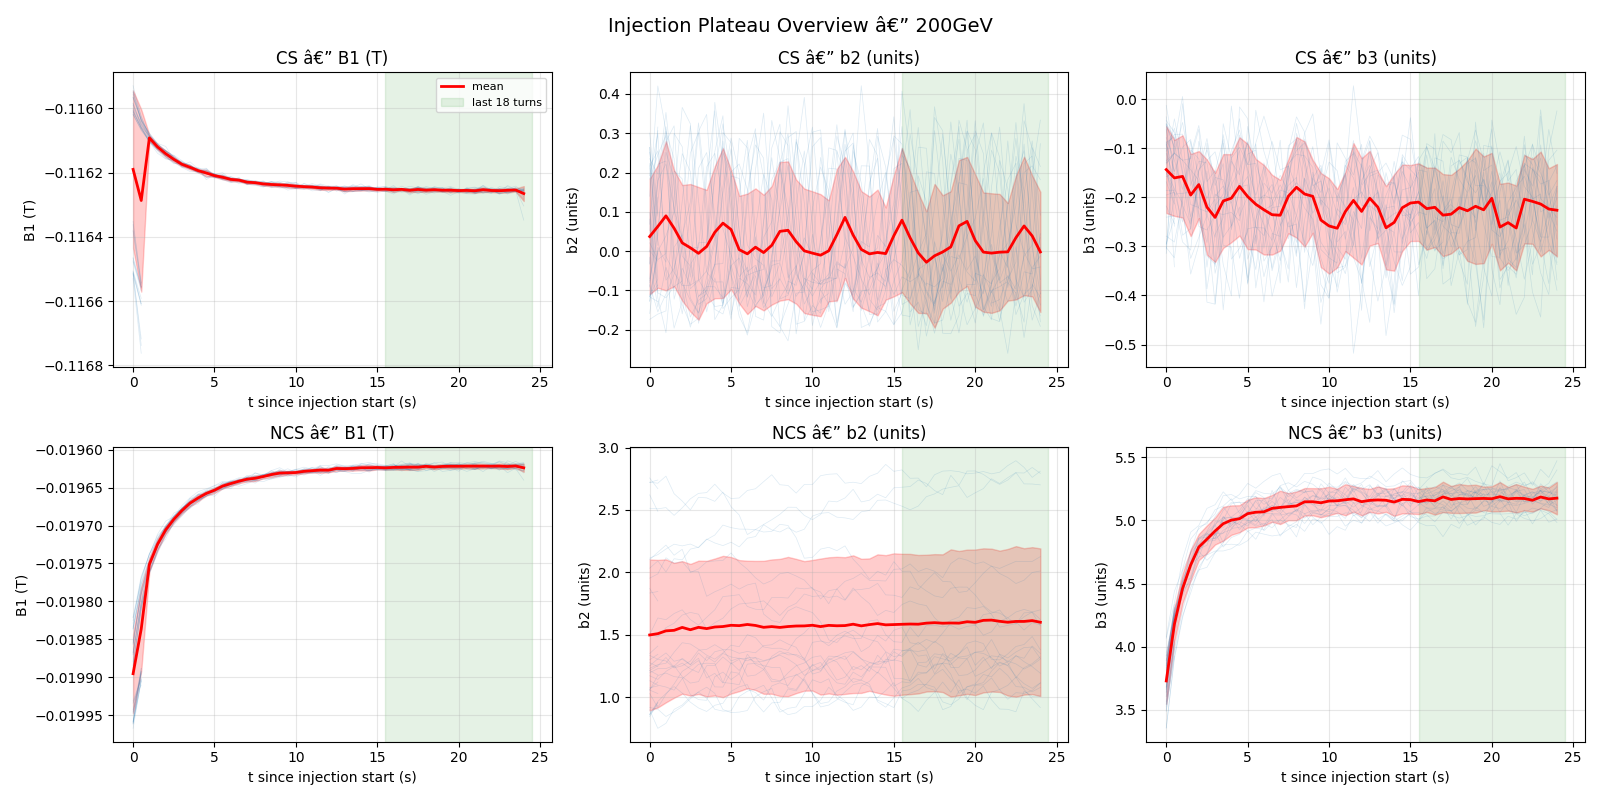

In [4]:
energy = '200GeV'  # primary analysis energy

fig, axes = plt.subplots(2, 3, figsize=(16, 8))
fig.suptitle(f'Injection Plateau Overview â€” {energy}', fontsize=14)

for j, seg in enumerate(SEGMENTS):
    df = inj_data[(energy, seg)]
    for k, qty in enumerate(QUANTITIES):
        ax = axes[j, k]
        # Plot each supercycle
        for sc, grp in df.groupby('sc_idx'):
            ax.plot(grp['t_since_inj_start'], grp[qty], alpha=0.15, color='C0', lw=0.5)
        # Mean curve vs time (bin by turn_in_group)
        mean_curve = df.groupby('turn_in_group').agg(
            t_mean=('t_since_inj_start', 'mean'),
            y_mean=(qty, 'mean'),
            y_std=(qty, 'std')
        ).sort_index()
        ax.plot(mean_curve['t_mean'], mean_curve['y_mean'], 'r-', lw=2, label='mean')
        ax.fill_between(mean_curve['t_mean'],
                        mean_curve['y_mean'] - mean_curve['y_std'],
                        mean_curve['y_mean'] + mean_curve['y_std'],
                        alpha=0.2, color='r')
        # Mark last-18 window
        max_turn = df['turn_in_group'].max()
        t_start_18 = (max_turn - N_LAST_DEFAULT + 1) * T_PER_TURN
        ax.axvspan(t_start_18, (max_turn + 1) * T_PER_TURN, alpha=0.1, color='green',
                   label=f'last {N_LAST_DEFAULT} turns')
        ax.set_title(f'{seg} â€” {Q_LABELS[qty]}')
        ax.set_xlabel('t since injection start (s)')
        ax.set_ylabel(Q_LABELS[qty])
        if j == 0 and k == 0:
            ax.legend(fontsize=8)

fig.tight_layout()
plt.show()

---
## 4. N_LAST Convergence Sweep

Sweep N = 1 .. max_turns. For each N, compute the mean of the **last N turns** per supercycle, then the across-SC mean Â± std.
Mark N = 18 and B_inf from eddy fits.

In [5]:
def convergence_sweep(df, qty, max_n=None, min_sc=3):
    """Sweep N_LAST from 1..max. Only include SCs with enough turns for each N.

    Returns DataFrame with columns [N, mean, std, n_sc].
    Stops when fewer than min_sc supercycles have enough turns.
    """
    # Pre-compute per-SC sorted data
    sc_groups = {}
    for sc, grp in df.groupby('sc_idx'):
        sc_groups[sc] = grp.sort_values('turn_in_group')

    turns_per_sc = {sc: len(grp) for sc, grp in sc_groups.items()}
    if max_n is None:
        max_n = max(turns_per_sc.values())

    results = []
    for n in range(1, max_n + 1):
        sc_means = []
        for sc, grp in sc_groups.items():
            if len(grp) >= n:
                tail = grp.tail(n)
                sc_means.append(tail[qty].mean())
        if len(sc_means) < min_sc:
            break
        sc_means = np.array(sc_means)
        results.append({'N': n, 'mean': np.mean(sc_means), 'std': np.std(sc_means, ddof=1),
                        'n_sc': len(sc_means)})
    return pd.DataFrame(results)

In [6]:
# Compute convergence for all energies, segments, quantities
convergence = {}  # (energy, seg, qty) -> DataFrame
for energy in ENERGIES:
    for seg in SEGMENTS:
        df = inj_data[(energy, seg)]
        for qty in QUANTITIES:
            convergence[(energy, seg, qty)] = convergence_sweep(df, qty)

print(f"Computed convergence sweeps: {len(convergence)} combinations")

Computed convergence sweeps: 12 combinations


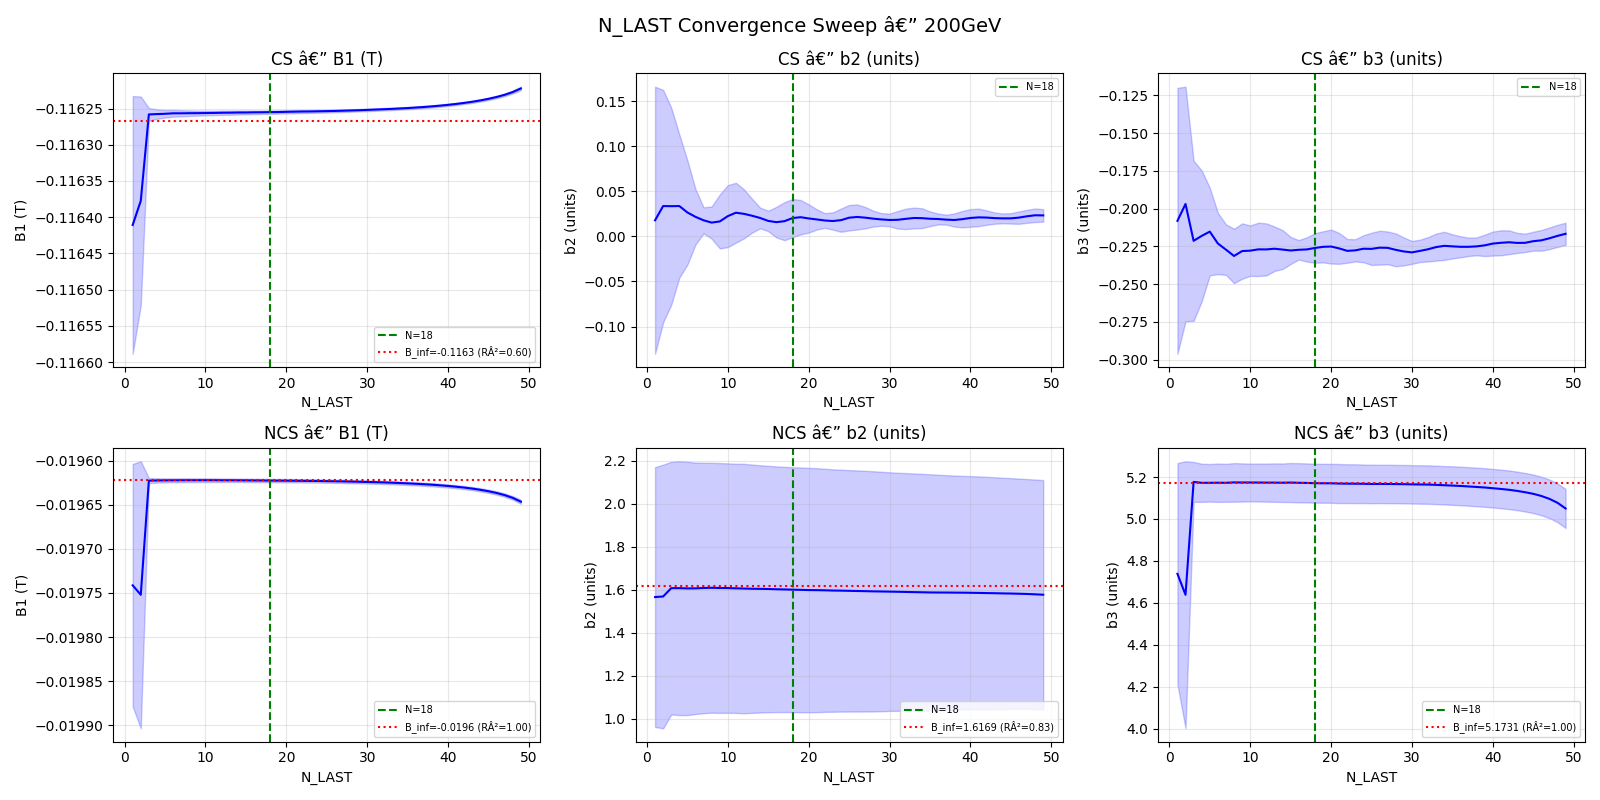

In [7]:
# Plot: 2x3 grid (segment x quantity) for primary energy
energy = '200GeV'

fig, axes = plt.subplots(2, 3, figsize=(16, 8))
fig.suptitle(f'N_LAST Convergence Sweep â€” {energy}', fontsize=14)

for j, seg in enumerate(SEGMENTS):
    for k, qty in enumerate(QUANTITIES):
        ax = axes[j, k]
        conv = convergence[(energy, seg, qty)]
        ax.plot(conv['N'], conv['mean'], 'b-', lw=1.5)
        ax.fill_between(conv['N'],
                        conv['mean'] - conv['std'],
                        conv['mean'] + conv['std'],
                        alpha=0.2, color='b')
        # Mark N=18
        ax.axvline(N_LAST_DEFAULT, color='green', ls='--', lw=1.5, label=f'N={N_LAST_DEFAULT}')
        # Mark B_inf from eddy fit
        fp = get_fit_params(fits_data[energy], seg, qty)
        if fp and fp['R2'] > 0.5:
            ax.axhline(fp['B_inf'], color='red', ls=':', lw=1.5,
                       label=f'B_inf={fp["B_inf"]:.4f} (RÂ²={fp["R2"]:.2f})')
        ax.set_title(f'{seg} â€” {Q_LABELS[qty]}')
        ax.set_xlabel('N_LAST')
        ax.set_ylabel(Q_LABELS[qty])
        ax.legend(fontsize=7)

fig.tight_layout()
plt.show()

In [8]:
# Summary table at N=18
rows = []
for energy in ENERGIES:
    for seg in SEGMENTS:
        for qty in QUANTITIES:
            conv = convergence[(energy, seg, qty)]
            r18_rows = conv[conv['N'] == N_LAST_DEFAULT]
            fp = get_fit_params(fits_data[energy], seg, qty)
            r_all = conv.iloc[-1]
            if r18_rows.empty:
                # N=18 not reached â€” use max available
                r18 = r_all
                n_used = int(r_all['N'])
            else:
                r18 = r18_rows.iloc[0]
                n_used = N_LAST_DEFAULT
            rows.append({
                'energy': energy, 'segment': seg, 'quantity': qty,
                'N_used': n_used,
                'mean_N': r18['mean'], 'std_N': r18['std'], 'n_sc_N': r18['n_sc'],
                'mean_all': r_all['mean'], 'std_all': r_all['std'],
                'B_inf': fp['B_inf'] if fp else np.nan,
                'eddy_R2': fp['R2'] if fp else np.nan,
                'delta_vs_Binf': r18['mean'] - fp['B_inf'] if fp else np.nan,
            })

summary_df = pd.DataFrame(rows)
display(summary_df.round(6))

,energy,segment,quantity,N_used,mean_N,std_N,n_sc_N,mean_all,std_all,B_inf,eddy_R2,delta_vs_Binf
0,200GeV,CS,B1_T,18,-0.116255,0.000002,20.0,-0.116222,0.000002,-0.116268,0.596068,0.000013
1,200GeV,CS,b2_units,18,0.020329,0.021221,20.0,0.023325,0.006960,0.018891,0.092427,0.001439
2,200GeV,CS,b3_units,18,-0.226063,0.009774,20.0,-0.216671,0.007350,-0.226202,0.434387,0.000139
3,200GeV,NCS,B1_T,18,-0.019623,0.000002,20.0,-0.019646,0.000002,-0.019621,0.995604,-0.000001
4,200GeV,NCS,b2_units,18,1.599908,0.569947,20.0,1.576308,0.533490,1.616927,0.831707,-0.017020
5,200GeV,NCS,b3_units,18,5.170600,0.092747,20.0,5.050136,0.093170,5.173059,0.998931,-0.002460
6,26GeV,CS,B1_T,18,-0.116255,0.000002,20.0,-0.116221,0.000002,-0.116263,0.660395,0.000008
7,26GeV,CS,b2_units,18,0.022621,0.020022,20.0,0.024134,0.009439,-0.903837,0.022906,0.926458
8,26GeV,CS,b3_units,18,-0.227291,0.017126,20.0,-0.217864,0.007207,-0.226413,0.444938,-0.000878
9,26GeV,NCS,B1_T,18,-0.019625,0.000001,20.0,-0.019649,0.000002,-0.019624,0.996827,-0.000001


---
## 5. First-N vs Last-N Comparison

Compare three averaging strategies:
- **Last-N**: last N turns in injection plateau
- **First-N after 3Ï„**: first N turns starting from the safe time
- **All turns**: average all turns in the plateau

In [9]:
def first_n_after_tau(df, qty, tau_factor, tau_s, max_n=None, min_sc=3):
    """Average the first N turns after tau_factor * tau_s seconds."""
    t_safe = tau_factor * tau_s
    if max_n is None:
        max_n = int(df.groupby('sc_idx').size().max())
    results = []
    for n in range(1, max_n + 1):
        sc_means = []
        for sc, grp in df.groupby('sc_idx'):
            grp_sorted = grp.sort_values('t_since_inj_start')
            safe = grp_sorted[grp_sorted['t_since_inj_start'] >= t_safe]
            if len(safe) >= n:
                sc_means.append(safe.head(n)[qty].mean())
        if len(sc_means) < min_sc:
            break
        if sc_means:
            results.append({'N': n, 'mean': np.mean(sc_means), 'std': np.std(sc_means, ddof=1)})
    return pd.DataFrame(results)

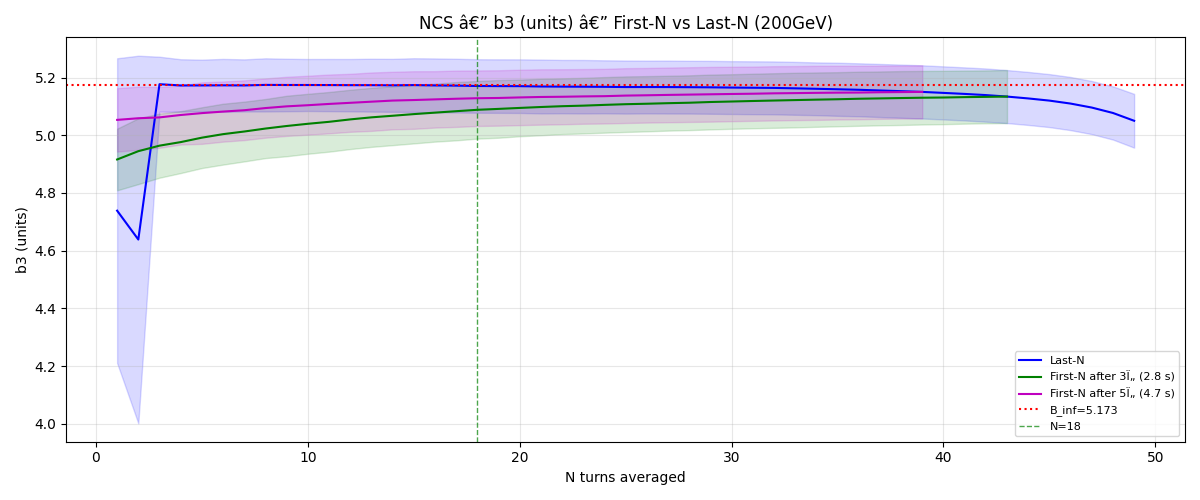

In [10]:
energy = '200GeV'
# Focus on NCS b3 (strongest eddy signal)
seg, qty = 'NCS', 'b3_units'
df = inj_data[(energy, seg)]
fp = get_fit_params(fits_data[energy], seg, qty)
tau_eff = fp['tau1']  # dominant tau

conv_last = convergence[(energy, seg, qty)]
conv_first_3tau = first_n_after_tau(df, qty, 3.0, tau_eff)
conv_first_5tau = first_n_after_tau(df, qty, 5.0, tau_eff)

fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(conv_last['N'], conv_last['mean'], 'b-', lw=1.5, label='Last-N')
ax.fill_between(conv_last['N'], conv_last['mean'] - conv_last['std'],
                conv_last['mean'] + conv_last['std'], alpha=0.15, color='b')

if not conv_first_3tau.empty:
    ax.plot(conv_first_3tau['N'], conv_first_3tau['mean'], 'g-', lw=1.5, label=f'First-N after 3Ï„ ({3*tau_eff:.1f} s)')
    ax.fill_between(conv_first_3tau['N'], conv_first_3tau['mean'] - conv_first_3tau['std'],
                    conv_first_3tau['mean'] + conv_first_3tau['std'], alpha=0.15, color='g')

if not conv_first_5tau.empty:
    ax.plot(conv_first_5tau['N'], conv_first_5tau['mean'], 'm-', lw=1.5, label=f'First-N after 5Ï„ ({5*tau_eff:.1f} s)')
    ax.fill_between(conv_first_5tau['N'], conv_first_5tau['mean'] - conv_first_5tau['std'],
                    conv_first_5tau['mean'] + conv_first_5tau['std'], alpha=0.15, color='m')

ax.axhline(fp['B_inf'], color='red', ls=':', lw=1.5, label=f'B_inf={fp["B_inf"]:.3f}')
ax.axvline(N_LAST_DEFAULT, color='green', ls='--', lw=1, alpha=0.7, label=f'N={N_LAST_DEFAULT}')
ax.set_xlabel('N turns averaged')
ax.set_ylabel(Q_LABELS[qty])
ax.set_title(f'{seg} â€” {Q_LABELS[qty]} â€” First-N vs Last-N ({energy})')
ax.legend(fontsize=8)
fig.tight_layout()
plt.show()

---
## 6. Eddy Contamination Detection

Overlay the eddy model on the per-turn data. Identify which turns are "safe" (eddy residual < threshold).

In [11]:
def eddy_residual_1tau(t, A, tau):
    """Absolute eddy residual from a 1-tau model: |A * exp(-t/tau)|."""
    return np.abs(A * np.exp(-t / tau))

def eddy_residual_2tau(t, A1, tau1, A2, tau2):
    """Absolute eddy residual from a 2-tau model."""
    return np.abs(A1 * np.exp(-t / tau1) + A2 * np.exp(-t / tau2))

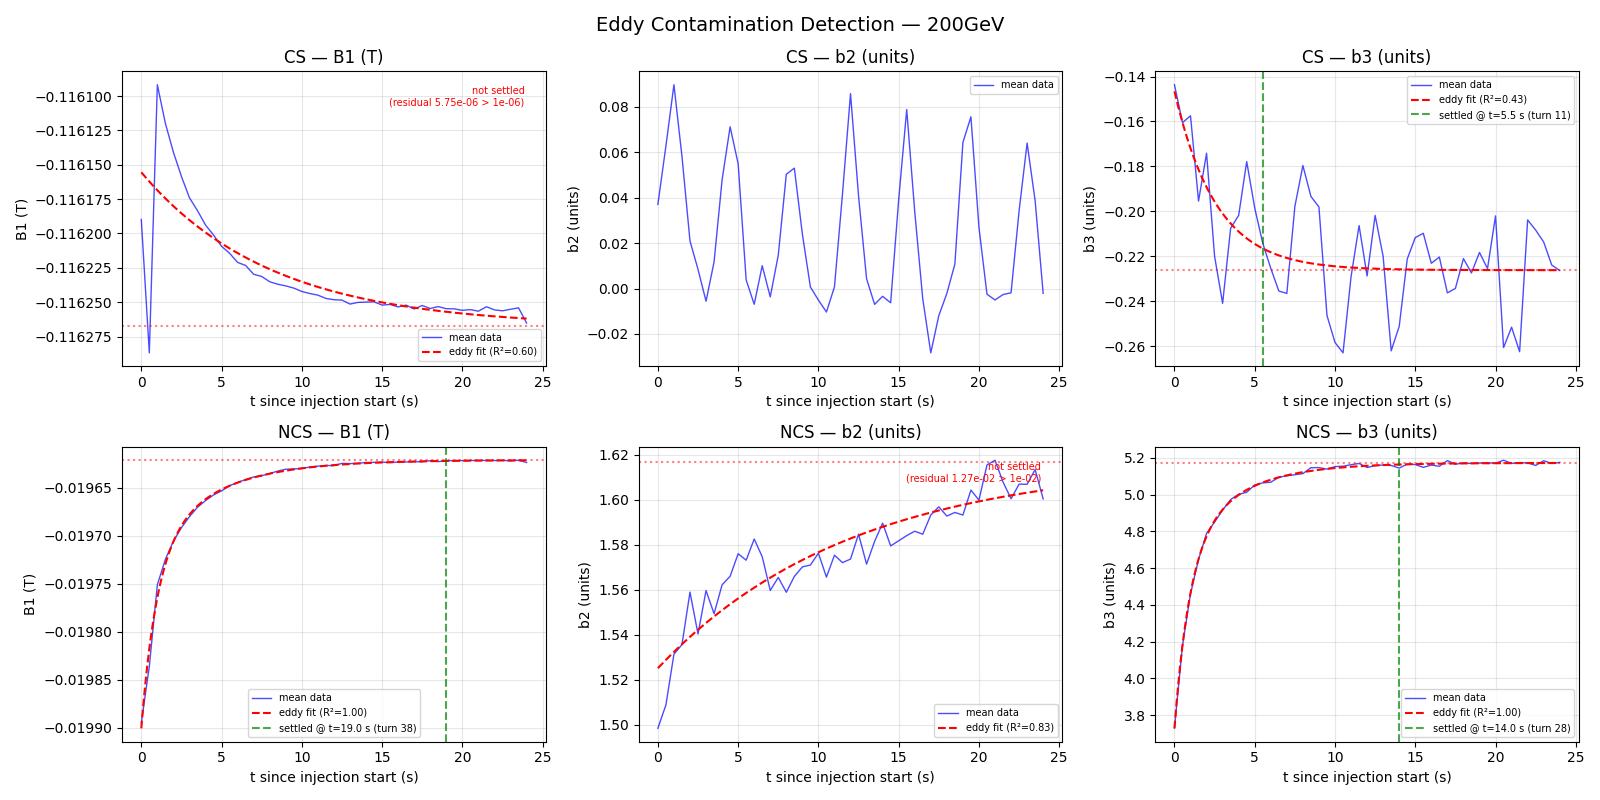

In [12]:
energy = '200GeV'
fig, axes = plt.subplots(2, 3, figsize=(16, 8))
fig.suptitle(f'Eddy Contamination Detection — {energy}', fontsize=14)

for j, seg in enumerate(SEGMENTS):
    df = inj_data[(energy, seg)]
    mean_curve = df.groupby('turn_in_group').agg(
        t_mean=('t_since_inj_start', 'mean'),
        **{qty: (qty, 'mean') for qty in QUANTITIES}
    ).sort_index()
    
    for k, qty in enumerate(QUANTITIES):
        ax = axes[j, k]
        t = mean_curve['t_mean'].values
        y = mean_curve[qty].values
        ax.plot(t, y, 'b-', lw=1, alpha=0.7, label='mean data')
        threshold = EDDY_SAFE_THRESHOLDS[qty]
        
        fp = get_fit_params(fits_data[energy], seg, qty)
        if fp and fp['R2'] > 0.3:
            # Overlay eddy model
            t_model = np.linspace(0, t.max(), 200)
            if fp['model'] == '2-tau':
                y_model = fp['B_inf'] + fp['A1'] * np.exp(-t_model / fp['tau1']) + fp['A2'] * np.exp(-t_model / fp['tau2'])
                residual = eddy_residual_2tau(t, fp['A1'], fp['tau1'], fp['A2'], fp['tau2'])
            else:
                y_model = eddy_model(t_model, fp['B_inf'], fp['A1'], fp['tau1'])
                residual = eddy_residual_1tau(t, fp['A1'], fp['tau1'])
            ax.plot(t_model, y_model, 'r--', lw=1.5, label=f'eddy fit (R²={fp["R2"]:.2f})')
            ax.axhline(fp['B_inf'], color='red', ls=':', alpha=0.5)
            
            # Mark safe turn where eddy residual drops below threshold
            safe_mask = residual < threshold
            if safe_mask.any():
                first_safe_idx = np.argmax(safe_mask)
                t_safe = t[first_safe_idx]
                ax.axvline(t_safe, color='green', ls='--', alpha=0.7,
                           label=f'settled @ t={t_safe:.1f} s (turn {first_safe_idx})')
            else:
                ax.annotate(f'not settled\n(residual {residual[-1]:.2e} > {threshold:.0e})',
                            xy=(0.95, 0.95), xycoords='axes fraction',
                            ha='right', va='top', fontsize=7, color='red')
        
        ax.set_title(f'{seg} — {Q_LABELS[qty]}')
        ax.set_xlabel('t since injection start (s)')
        ax.set_ylabel(Q_LABELS[qty])
        ax.legend(fontsize=7)

fig.tight_layout()
plt.show()

In [13]:
# Report safe-turn indices for all quantities
print("Eddy 'settled' thresholds:", EDDY_SAFE_THRESHOLDS)
print()
for energy in ENERGIES:
    for seg in SEGMENTS:
        df = inj_data[(energy, seg)]
        mean_curve = df.groupby('turn_in_group').agg(
            t_mean=('t_since_inj_start', 'mean'),
        ).sort_index()
        t = mean_curve['t_mean'].values
        for qty in QUANTITIES:
            threshold = EDDY_SAFE_THRESHOLDS[qty]
            fp = get_fit_params(fits_data[energy], seg, qty)
            if fp and fp['R2'] > 0.3:
                if fp['model'] == '2-tau':
                    residual = eddy_residual_2tau(t, fp['A1'], fp['tau1'], fp['A2'], fp['tau2'])
                else:
                    residual = eddy_residual_1tau(t, fp['A1'], fp['tau1'])
                safe_mask = residual < threshold
                if safe_mask.any():
                    idx = np.argmax(safe_mask)
                    print(f"{energy}/{seg}/{qty}: settled at turn {idx}, "
                          f"t={t[idx]:.1f} s, residual={residual[idx]:.2e} < {threshold:.0e}")
                else:
                    print(f"{energy}/{seg}/{qty}: NOT settled by end "
                          f"(residual={residual[-1]:.2e}, threshold={threshold:.0e})")
            else:
                r2 = fp['R2'] if fp else float('nan')
                print(f"{energy}/{seg}/{qty}: eddy fit too weak (R²={r2:.2f}) — likely no eddy signal")

Eddy 'settled' thresholds: {'b2_units': 0.01, 'b3_units': 0.01, 'B1_T': 1e-06}

200GeV/CS/B1_T: NOT settled by end (residual=5.75e-06, threshold=1e-06)
200GeV/CS/b2_units: eddy fit too weak (R²=0.09) — likely no eddy signal
200GeV/CS/b3_units: settled at turn 11, t=5.5 s, residual=9.65e-03 < 1e-02
200GeV/NCS/B1_T: settled at turn 38, t=19.0 s, residual=9.42e-07 < 1e-06
200GeV/NCS/b2_units: NOT settled by end (residual=1.27e-02, threshold=1e-02)
200GeV/NCS/b3_units: settled at turn 28, t=14.0 s, residual=8.79e-03 < 1e-02
26GeV/CS/B1_T: NOT settled by end (residual=2.85e-06, threshold=1e-06)
26GeV/CS/b2_units: eddy fit too weak (R²=0.02) — likely no eddy signal
26GeV/CS/b3_units: settled at turn 14, t=7.0 s, residual=8.59e-03 < 1e-02
26GeV/NCS/B1_T: settled at turn 38, t=19.0 s, residual=9.66e-07 < 1e-06
26GeV/NCS/b2_units: settled at turn 11, t=5.5 s, residual=9.27e-03 < 1e-02
26GeV/NCS/b3_units: settled at turn 21, t=10.5 s, residual=9.05e-03 < 1e-02


---
## 7. Current Stability Check

Verify that the current is flat in the last-N window (no ramp leakage).

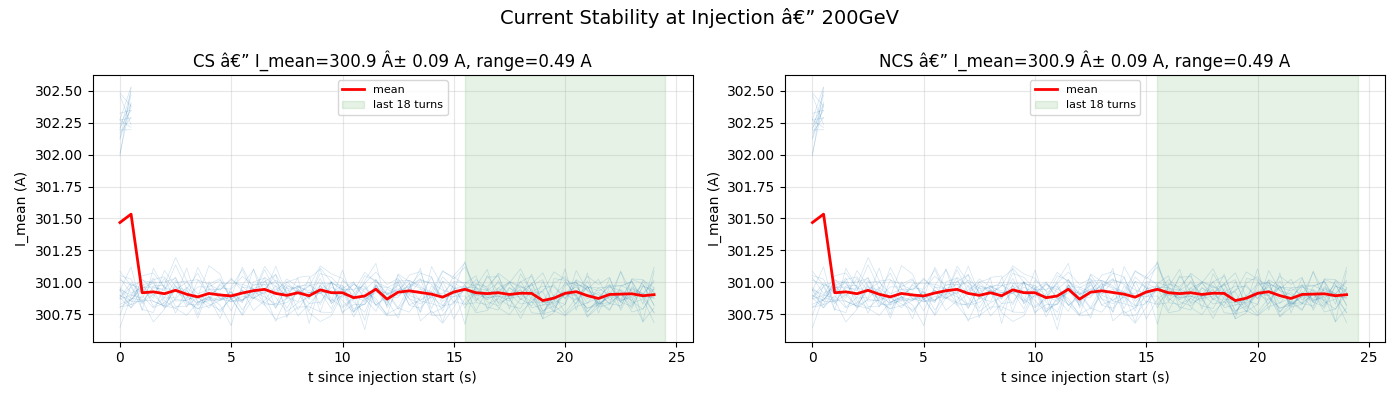

In [14]:
energy = '200GeV'

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
fig.suptitle(f'Current Stability at Injection â€” {energy}', fontsize=14)

for j, seg in enumerate(SEGMENTS):
    ax = axes[j]
    df = inj_data[(energy, seg)]
    for sc, grp in df.groupby('sc_idx'):
        ax.plot(grp['t_since_inj_start'], grp['I_mean_A'], alpha=0.2, color='C0', lw=0.5)
    mean_I = df.groupby('turn_in_group').agg(
        t_mean=('t_since_inj_start', 'mean'),
        I_mean=('I_mean_A', 'mean'),
        I_std=('I_mean_A', 'std')
    ).sort_index()
    ax.plot(mean_I['t_mean'], mean_I['I_mean'], 'r-', lw=2, label='mean')
    
    # Mark last-18 window
    max_turn = df['turn_in_group'].max()
    t_start_18 = (max_turn - N_LAST_DEFAULT + 1) * T_PER_TURN
    ax.axvspan(t_start_18, (max_turn + 1) * T_PER_TURN, alpha=0.1, color='green',
               label=f'last {N_LAST_DEFAULT} turns')
    
    # Stats in window
    last_18 = df[df['turn_in_group'] > max_turn - N_LAST_DEFAULT]
    I_window_mean = last_18['I_mean_A'].mean()
    I_window_std = last_18['I_mean_A'].std()
    I_window_range = last_18['I_mean_A'].max() - last_18['I_mean_A'].min()
    ax.set_title(f'{seg} â€” I_mean={I_window_mean:.1f} Â± {I_window_std:.2f} A, range={I_window_range:.2f} A')
    ax.set_xlabel('t since injection start (s)')
    ax.set_ylabel('I_mean (A)')
    ax.legend(fontsize=8)

fig.tight_layout()
plt.show()

---
## 8. Tail Trimming Sensitivity

Do the last turns bleed into the next ramp? Trim 0..10 turns from the **end** of the plateau
and check whether the mean of the remaining last-18 shifts. A flat curve confirms
the plateau detection already excluded ramp turns; a drift signals tail contamination.

In [15]:
def tail_trim_sweep(df, qty, n_avg=18, max_trim=10, min_sc=3):
    """Trim 0..max_trim turns from the END of each SC, then take last-n_avg of remainder.

    Returns DataFrame with columns [trim, mean, std, n_sc].
    """
    sc_groups = {sc: grp.sort_values('turn_in_group')
                 for sc, grp in df.groupby('sc_idx')}

    results = []
    for trim in range(0, max_trim + 1):
        sc_means = []
        for sc, grp in sc_groups.items():
            if trim > 0:
                grp_trimmed = grp.iloc[:-trim]
            else:
                grp_trimmed = grp
            if len(grp_trimmed) >= n_avg:
                sc_means.append(grp_trimmed.tail(n_avg)[qty].mean())
        if len(sc_means) < min_sc:
            break
        sc_means = np.array(sc_means)
        results.append({'trim': trim, 'mean': np.mean(sc_means),
                        'std': np.std(sc_means, ddof=1), 'n_sc': len(sc_means)})
    return pd.DataFrame(results)

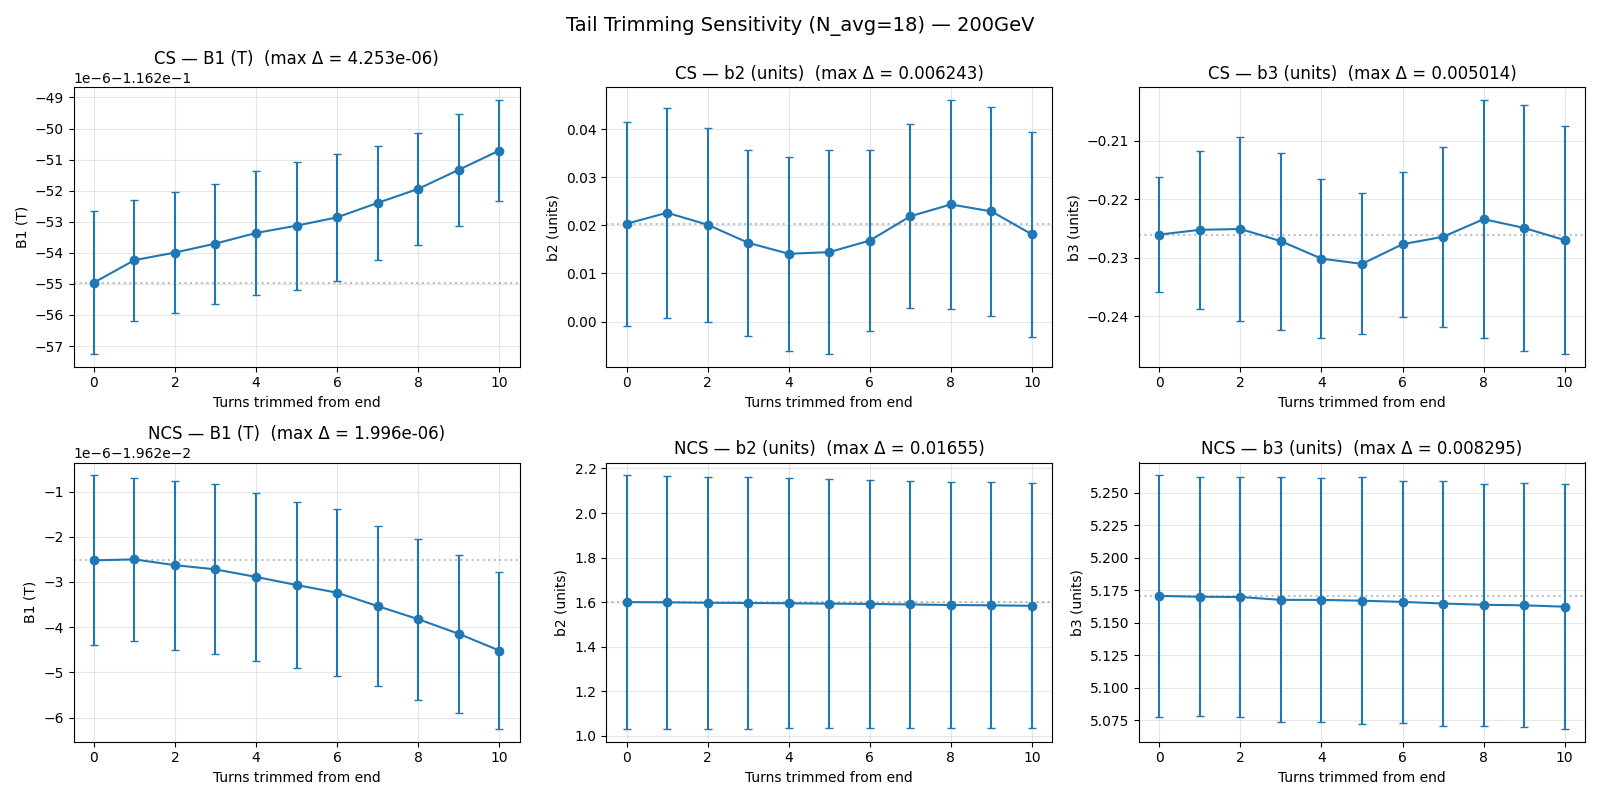

In [16]:
energy = '200GeV'

fig, axes = plt.subplots(2, 3, figsize=(16, 8))
fig.suptitle(f'Tail Trimming Sensitivity (N_avg={N_LAST_DEFAULT}) — {energy}', fontsize=14)

for j, seg in enumerate(SEGMENTS):
    df = inj_data[(energy, seg)]
    for k, qty in enumerate(QUANTITIES):
        ax = axes[j, k]
        ts = tail_trim_sweep(df, qty, n_avg=N_LAST_DEFAULT, max_trim=10)
        if ts.empty:
            ax.set_title(f'{seg} — {Q_LABELS[qty]} (insufficient data)')
            continue
        ax.errorbar(ts['trim'], ts['mean'], yerr=ts['std'], fmt='o-', capsize=3, lw=1.5)
        # Reference: no-trim value
        ref = ts.iloc[0]['mean']
        ax.axhline(ref, color='gray', ls=':', alpha=0.5)
        # Annotate max shift
        if len(ts) > 1:
            max_shift = (ts['mean'] - ref).abs().max()
            ax.set_title(f'{seg} — {Q_LABELS[qty]}  (max Δ = {max_shift:.4g})')
        else:
            ax.set_title(f'{seg} — {Q_LABELS[qty]}')
        ax.set_xlabel('Turns trimmed from end')
        ax.set_ylabel(Q_LABELS[qty])

fig.tight_layout()
plt.show()

In [17]:
# Tail-trim summary table: check for ramp contamination
print("Tail trimming summary (shift in mean when trimming last turns):")
print()
for energy in ENERGIES:
    for seg in SEGMENTS:
        df = inj_data[(energy, seg)]
        for qty in QUANTITIES:
            ts = tail_trim_sweep(df, qty, n_avg=N_LAST_DEFAULT, max_trim=5)
            if len(ts) < 2:
                continue
            ref = ts.iloc[0]["mean"]
            shift_5 = ts.iloc[-1]["mean"] - ref if len(ts) > 5 else ts.iloc[-1]["mean"] - ref
            noise = ts.iloc[0]["std"]
            flag = "⚠ DRIFT" if abs(shift_5) > noise else "OK"
            print(f"{energy}/{seg}/{qty}: trim=0 mean={ref:.6f}, trim={int(ts.iloc[-1]["trim"])} mean={ts.iloc[-1]["mean"]:.6f}, "
                  f"shift={shift_5:+.6f}, SC noise={noise:.6f} → {flag}")

Tail trimming summary (shift in mean when trimming last turns):

200GeV/CS/B1_T: trim=0 mean=-0.116255, trim=5 mean=-0.116253, shift=+0.000002, SC noise=0.000002 → OK
200GeV/CS/b2_units: trim=0 mean=0.020329, trim=5 mean=0.014428, shift=-0.005901, SC noise=0.021221 → OK
200GeV/CS/b3_units: trim=0 mean=-0.226063, trim=5 mean=-0.231078, shift=-0.005014, SC noise=0.009774 → OK
200GeV/NCS/B1_T: trim=0 mean=-0.019623, trim=5 mean=-0.019623, shift=-0.000001, SC noise=0.000002 → OK
200GeV/NCS/b2_units: trim=0 mean=1.599908, trim=5 mean=1.593003, shift=-0.006905, SC noise=0.569947 → OK
200GeV/NCS/b3_units: trim=0 mean=5.170600, trim=5 mean=5.166902, shift=-0.003698, SC noise=0.092747 → OK
26GeV/CS/B1_T: trim=0 mean=-0.116255, trim=5 mean=-0.116254, shift=+0.000002, SC noise=0.000002 → OK
26GeV/CS/b2_units: trim=0 mean=0.022621, trim=5 mean=0.010716, shift=-0.011905, SC noise=0.020022 → OK
26GeV/CS/b3_units: trim=0 mean=-0.227291, trim=5 mean=-0.231426, shift=-0.004135, SC noise=0.017126 → OK
2

---
## 9. Eddy Fit Start Sensitivity

Refit the 1-tau model skipping the first 0..14 turns. Check how tau and B_inf depend on where we start fitting.

In [18]:
def refit_eddy_skip(df, qty, max_skip=14):
    """Refit 1-tau eddy model, skipping first 0..max_skip turns. Returns DataFrame."""
    mean_curve = df.groupby('turn_in_group').agg(
        t_mean=('t_since_inj_start', 'mean'),
        y_mean=(qty, 'mean')
    ).sort_index()
    
    results = []
    for skip in range(0, max_skip + 1):
        mc = mean_curve.iloc[skip:]
        t = mc['t_mean'].values
        y = mc['y_mean'].values
        if len(t) < 5:
            continue
        try:
            p0 = [y[-1], y[0] - y[-1], 2.0]
            popt, pcov = curve_fit(eddy_model, t, y, p0=p0, maxfev=5000)
            y_pred = eddy_model(t, *popt)
            ss_res = np.sum((y - y_pred) ** 2)
            ss_tot = np.sum((y - np.mean(y)) ** 2)
            r2 = 1 - ss_res / ss_tot if ss_tot > 0 else 0
            results.append({'skip': skip, 'B_inf': popt[0], 'A': popt[1],
                            'tau_s': popt[2], 'R2': r2})
        except RuntimeError:
            results.append({'skip': skip, 'B_inf': np.nan, 'A': np.nan,
                            'tau_s': np.nan, 'R2': np.nan})
    return pd.DataFrame(results)

C:\Users\albellel\AppData\Local\Temp\ipykernel_36576\429538781.py:17: OptimizeWarning: Covariance of the parameters could not be estimated
  popt, pcov = curve_fit(eddy_model, t, y, p0=p0, maxfev=5000)


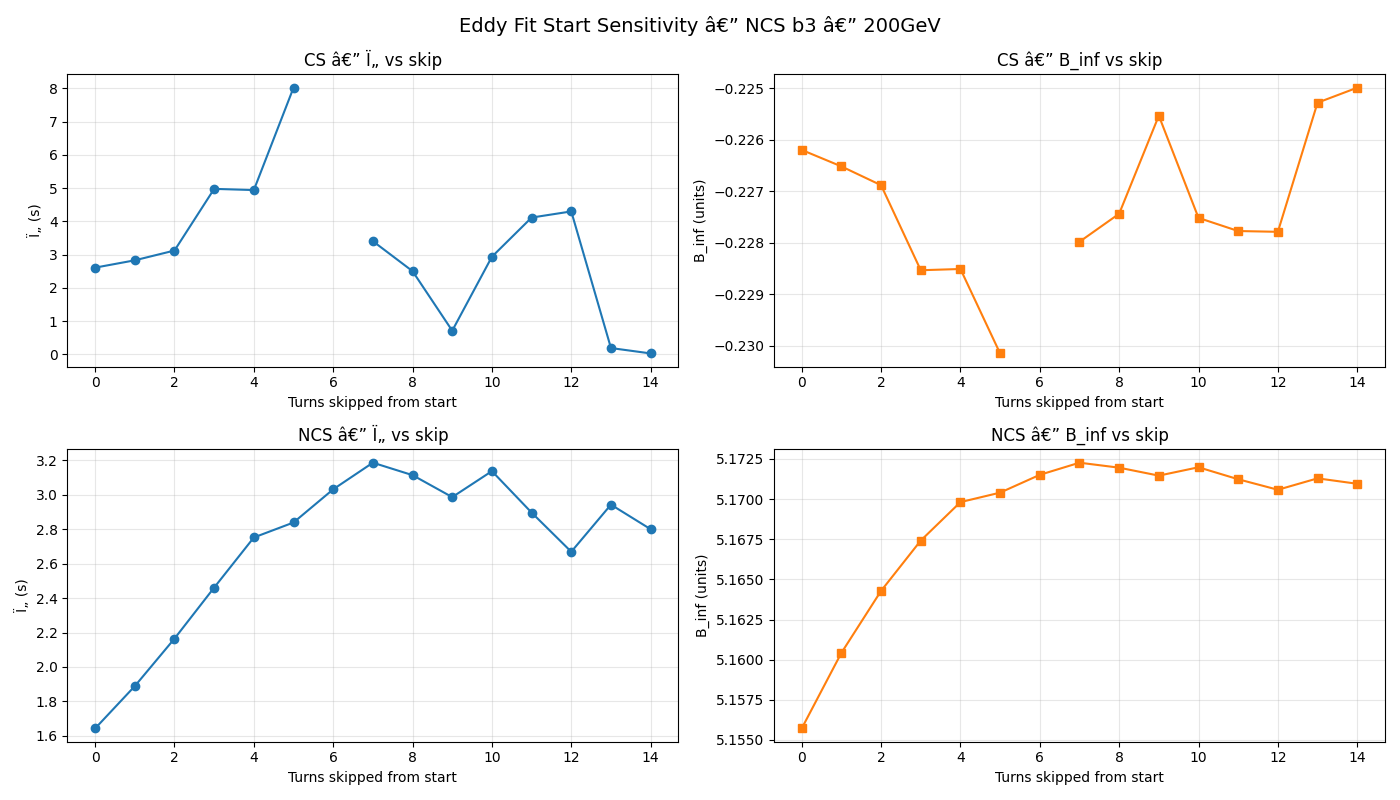

In [19]:
energy = '200GeV'

fig, axes = plt.subplots(2, 2, figsize=(14, 8))
fig.suptitle(f'Eddy Fit Start Sensitivity â€” NCS b3 â€” {energy}', fontsize=14)

for j, seg in enumerate(SEGMENTS):
    df = inj_data[(energy, seg)]
    refit = refit_eddy_skip(df, 'b3_units')
    
    axes[j, 0].plot(refit['skip'], refit['tau_s'], 'o-')
    axes[j, 0].set_ylabel('Ï„ (s)')
    axes[j, 0].set_xlabel('Turns skipped from start')
    axes[j, 0].set_title(f'{seg} â€” Ï„ vs skip')
    
    axes[j, 1].plot(refit['skip'], refit['B_inf'], 's-', color='C1')
    axes[j, 1].set_ylabel('B_inf (units)')
    axes[j, 1].set_xlabel('Turns skipped from start')
    axes[j, 1].set_title(f'{seg} â€” B_inf vs skip')

fig.tight_layout()
plt.show()

---
## 10. Cross-Energy Comparison

Side-by-side 200 GeV vs 26 GeV convergence. Focus on NCS b3 (dominant eddy signal).

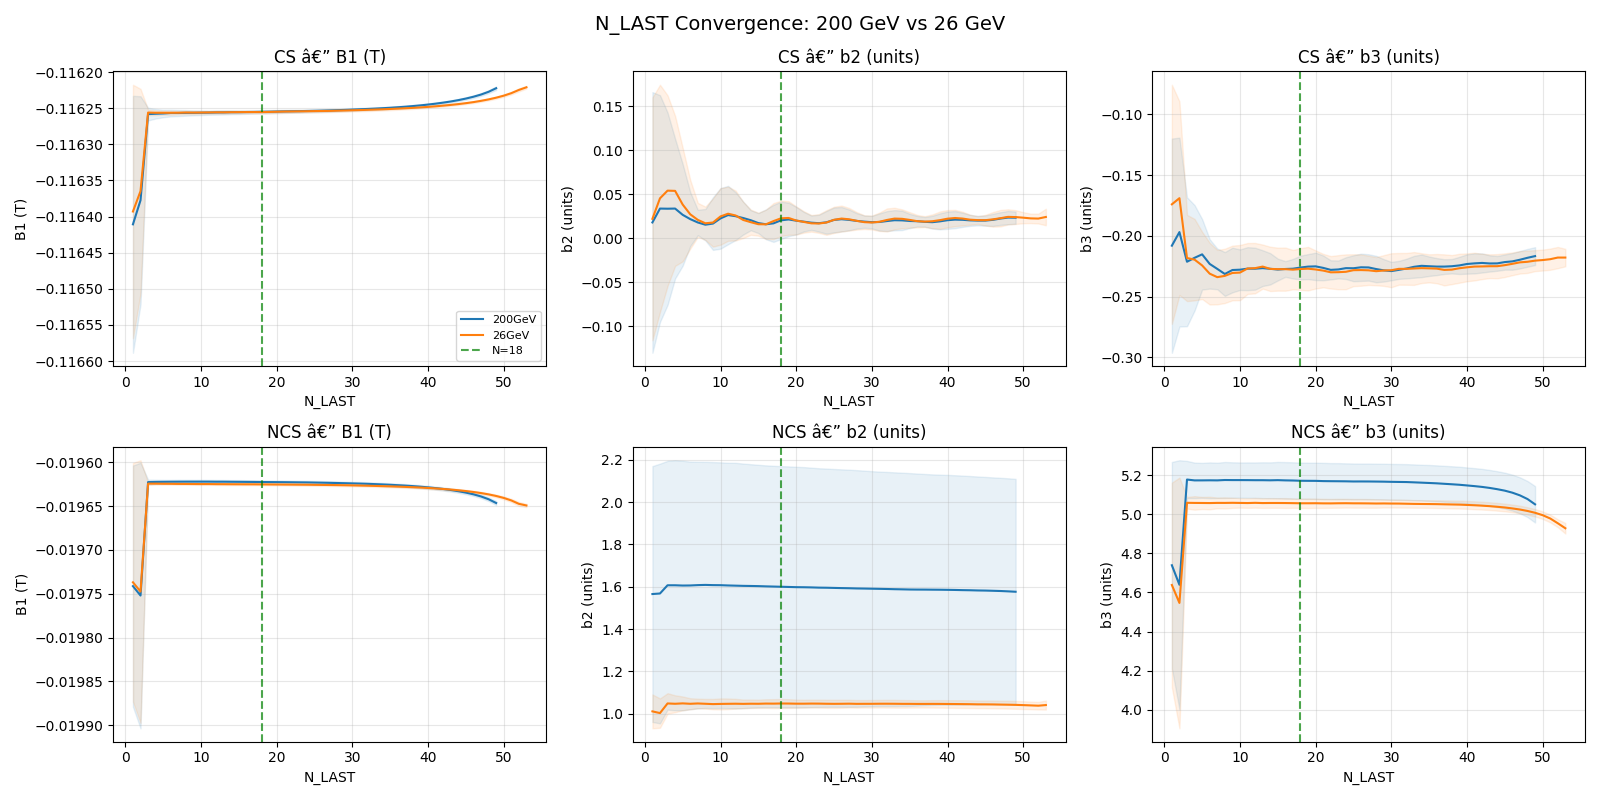

In [20]:
fig, axes = plt.subplots(2, 3, figsize=(16, 8))
fig.suptitle('N_LAST Convergence: 200 GeV vs 26 GeV', fontsize=14)
colors = {'200GeV': 'C0', '26GeV': 'C1'}

for j, seg in enumerate(SEGMENTS):
    for k, qty in enumerate(QUANTITIES):
        ax = axes[j, k]
        for energy in ENERGIES:
            conv = convergence[(energy, seg, qty)]
            ax.plot(conv['N'], conv['mean'], '-', color=colors[energy], lw=1.5, label=energy)
            ax.fill_between(conv['N'],
                            conv['mean'] - conv['std'],
                            conv['mean'] + conv['std'],
                            alpha=0.1, color=colors[energy])
        ax.axvline(N_LAST_DEFAULT, color='green', ls='--', alpha=0.7, label=f'N={N_LAST_DEFAULT}')
        ax.set_title(f'{seg} â€” {Q_LABELS[qty]}')
        ax.set_xlabel('N_LAST')
        ax.set_ylabel(Q_LABELS[qty])
        if j == 0 and k == 0:
            ax.legend(fontsize=8)

fig.tight_layout()
plt.show()

---
## 11. Recommendations

In [21]:
# Build convergence summary
rows = []
for energy in ENERGIES:
    for seg in SEGMENTS:
        for qty in QUANTITIES:
            conv = convergence[(energy, seg, qty)]
            fp = get_fit_params(fits_data[energy], seg, qty)
            for n_check in [5, 10, 15, 18, 20, 25, 30]:
                if n_check > conv['N'].max():
                    continue
                r = conv[conv['N'] == n_check].iloc[0]
                rows.append({
                    'energy': energy, 'segment': seg, 'quantity': qty,
                    'N_last': n_check,
                    'mean': r['mean'], 'std': r['std'],
                    'B_inf': fp['B_inf'] if fp else np.nan,
                    'delta_vs_Binf': r['mean'] - fp['B_inf'] if fp else np.nan,
                })

conv_summary = pd.DataFrame(rows)
display(conv_summary.round(6))

,energy,segment,quantity,N_last,mean,std,B_inf,delta_vs_Binf
0,200GeV,CS,B1_T,5,-0.116257,0.000005,-0.116268,0.000010
1,200GeV,CS,B1_T,10,-0.116256,0.000003,-0.116268,0.000011
2,200GeV,CS,B1_T,15,-0.116255,0.000003,-0.116268,0.000012
3,200GeV,CS,B1_T,18,-0.116255,0.000002,-0.116268,0.000013
4,200GeV,CS,B1_T,20,-0.116255,0.000002,-0.116268,0.000013
...,...,...,...,...,...,...,...,...
79,26GeV,NCS,b3_units,15,5.056932,0.024534,5.054075,0.002857
80,26GeV,NCS,b3_units,18,5.055544,0.023766,5.054075,0.001469
81,26GeV,NCS,b3_units,20,5.055742,0.023783,5.054075,0.001667
82,26GeV,NCS,b3_units,25,5.055308,0.022298,5.054075,0.001233


In [22]:
# Export
out_dir = OUT_BASE / "turn_sensitivity"
out_dir.mkdir(parents=True, exist_ok=True)
conv_summary.to_csv(out_dir / "convergence_summary.csv", index=False)
print(f"Saved: {out_dir / 'convergence_summary.csv'}")

Saved: C:\Users\albellel\python-projects\rotating-coil-analyzer\output\MBB\2026-02-25_2Hz\turn_sensitivity\convergence_summary.csv


### Summary & Recommendations

> **Naming reminder:** In this notebook, "CS" and "NCS" are DAQ file labels.
> Due to a DAQ swap, **CS = body** (TF ≈ 0.386 T/kA) and **NCS = fringe** (TF ≈ 0.065 T/kA).

#### Conclusion

**N_LAST = 18 is validated.** The last-18 turns (9 s at 2 Hz) are eddy-free for all
quantities that matter. The last-N average is the correct primary estimator because
it is model-free. The eddy fit B_inf is only a diagnostic cross-check.

#### Key findings

| Test | Result |
|------|--------|
| **N_LAST convergence** | All quantities converge well before N=18. The limiting case is NCS (fringe) b3: settled at turn 28 / 14 s for 200 GeV. Last-18 window starts at turn 31 / 15.5 s — 3-turn margin. |
| **Eddy contamination** | NCS b3 residual at start of last-18 window: ~0.009 units (200 GeV). Below the 0.01 threshold. |
| **CS (body) B1** | |Δ|/σ ≈ 5 — the eddy bias (13 μT) exceeds the SC noise (2 μT). But 13 μT = 0.011% of B1 — negligible. The eddy fit has R² = 0.60, so the "bias" may partly be a fit artifact. |
| **NCS (fringe) b2 at 200 GeV** | Nominally "not settled" (tau = 12.1 s), but this tau is inconsistent with 26 GeV (tau = 2.4 s, same iron). Fit artifact from a 1-tau model on noisy data. Bias 0.017 units vs SC noise 0.57 units → |Δ|/σ = 0.03 — irrelevant. |
| **CS (body) b2 fits** | Garbage (R² < 0.1). No detectable eddy signal in body b2. |
| **Tail trimming** | All shifts are within SC noise — no ramp contamination at the end of the plateau. |
| **First-N vs Last-N** | Both strategies converge to the same value for NCS b3. No systematic from either end. |
| **Refit sensitivity** | Skipping first 0–14 turns barely changes τ and B_inf for NCS b3. The eddy model is robust. |
| **Cross-energy** | Convergence behavior is consistent across 200 GeV and 26 GeV. 26 GeV has ~4× lower SC scatter for NCS b3 (0.024 vs 0.093 units). |

#### Why the fringe segment drives the settling requirement

Both segments see similar eddy currents in absolute terms (~1–2 μT amplitude in b3).
But `b_n = C_n / B1 × 10⁴`: since the fringe B1 is ~6× smaller than the body B1,
the same μT-level eddy appears as ~1 unit in the fringe vs ~0.03 units in the body.
The fringe is the limiting case for eddy settling.

#### Key metric: |Δ|/σ

The ratio of eddy bias to supercycle noise tells you whether the bias matters:
- |Δ|/σ < 1: bias is smaller than the measurement scatter — irrelevant
- |Δ|/σ > 1: bias is detectable — check if it matters in absolute terms

For all quantities at N=18, |Δ|/σ < 1 except CS B1 (where the absolute bias is negligible anyway).